# Demo I: soft constraints, a PINN on a damped harmonic oscillator

We observe a damped oscillator only at the **beginning** of its motion, with noise:

$$\ddot x + \mu \dot x + k x = 0, \qquad x(0)=1,\ \dot x(0)=0$$

Two networks with the same architecture are trained:

- **A, data only**: loss = mean squared error on the observed points.
- **B, PINN**: same loss + the ODE residual evaluated (by autodiff) on
  collocation points spread over the **whole** time window.

Bonus **C**: a PINN given the *wrong* physics ($k$ off by 45%).

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)
t_start = time.time()

BLUE, RED, GREEN, ORANGE, GREY = "#5073B8", "#B85050", "#50B873", "#EBA05A", "#888888"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

## The physical system and the data

In [2]:
d, w0 = 2.0, 20.0          # damping rate and natural frequency
mu, k = 2 * d, w0**2       # ODE coefficients


def exact(t):
    """Analytic solution of the under-damped oscillator."""
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d / w)
    A = 1 / (2 * np.cos(phi))
    return np.exp(-d * t) * 2 * A * np.cos(phi + w * t)


t_dense = np.linspace(0, 1, 500)
t_obs = np.linspace(0, 0.36, 10)
x_obs = exact(t_obs) + 0.04 * np.random.randn(len(t_obs))

t_obs_t = torch.tensor(t_obs, dtype=torch.float32).view(-1, 1)
x_obs_t = torch.tensor(x_obs, dtype=torch.float32).view(-1, 1)
t_col = torch.linspace(0, 1, 60).view(-1, 1).requires_grad_(True)   # collocation points
t_dense_t = torch.tensor(t_dense, dtype=torch.float32).view(-1, 1)

## Model and training loop
The only difference between A, B and C is the loss.

In [3]:
def mlp():
    return torch.nn.Sequential(
        torch.nn.Linear(1, 32), torch.nn.Tanh(),
        torch.nn.Linear(32, 32), torch.nn.Tanh(),
        torch.nn.Linear(32, 32), torch.nn.Tanh(),
        torch.nn.Linear(32, 1),
    )


def ode_residual(model, t, mu, k):
    x = model(t)
    dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    d2x = torch.autograd.grad(dx, t, torch.ones_like(dx), create_graph=True)[0]
    return d2x + mu * dx + k * x


def train(physics=None, steps=20000, lam=1e-4):
    """physics=None: data only. physics=(mu, k): add the ODE residual to the loss."""
    torch.manual_seed(1)
    model = mlp()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = []
    for step in range(steps):
        opt.zero_grad()
        loss_data = torch.mean((model(t_obs_t) - x_obs_t) ** 2)
        loss = loss_data
        if physics is not None:
            loss_phys = torch.mean(ode_residual(model, t_col, *physics) ** 2)
            loss = loss + lam * loss_phys
        loss.backward()
        opt.step()
        if step % 100 == 0:
            history.append((step, loss_data.item(),
                            loss_phys.item() * lam if physics is not None else np.nan))
    return model, np.array(history)


model_A, hist_A = train(physics=None)
model_B, hist_B = train(physics=(mu, k))
model_C, hist_C = train(physics=(mu, 0.55 * k))   # wrong stiffness: k off by 45%

with torch.no_grad():
    pred = {name: m(t_dense_t).numpy().ravel() for name, m in
            [("A", model_A), ("B", model_B), ("C", model_C)]}

for name in "ABC":
    rmse = np.sqrt(np.mean((pred[name] - exact(t_dense)) ** 2))
    print(f"model {name}: RMSE over the whole window = {rmse:.3f}")

model A: RMSE over the whole window = 0.662
model B: RMSE over the whole window = 0.032
model C: RMSE over the whole window = 0.284


## Results: with vs without the physics

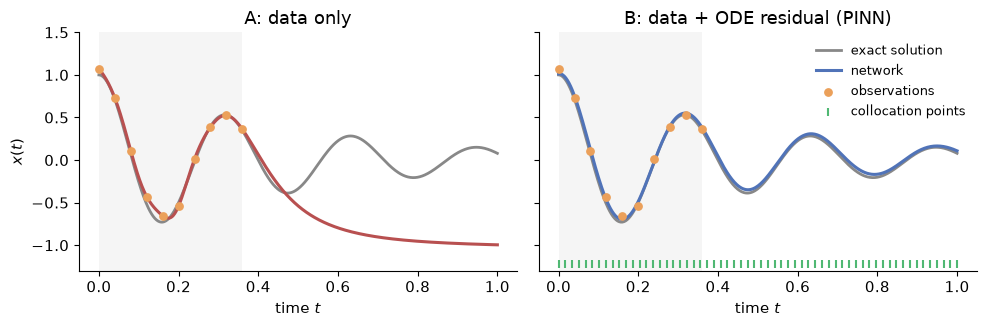

In [4]:
def panel(ax, y, color, title):
    ax.axvspan(0, t_obs.max(), color=GREY, alpha=0.08, lw=0)
    ax.plot(t_dense, exact(t_dense), color=GREY, lw=2, label="exact solution")
    ax.plot(t_dense, y, color=color, lw=2.2, label="network")
    ax.scatter(t_obs, x_obs, color=ORANGE, zorder=5, s=28, label="observations")
    ax.set_ylim(-1.3, 1.5)
    ax.set_xlabel("time $t$")
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
panel(axes[0], pred["A"], RED, "A: data only")
panel(axes[1], pred["B"], BLUE, "B: data + ODE residual (PINN)")
axes[1].scatter(t_col.detach().numpy().ravel(), np.full(60, -1.22), marker="|",
                color=GREEN, s=40, label="collocation points")
axes[0].set_ylabel("$x(t)$")
axes[1].legend(loc="upper right", fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig("figures/fig_I_oscillator.pdf")
plt.show()

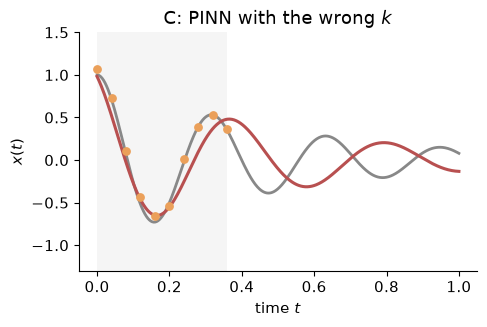

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.4))
panel(ax, pred["C"], RED, "C: PINN with the wrong $k$")
ax.set_ylabel("$x(t)$")
fig.tight_layout()
fig.savefig("figures/fig_I_wrong_physics.pdf")
plt.show()

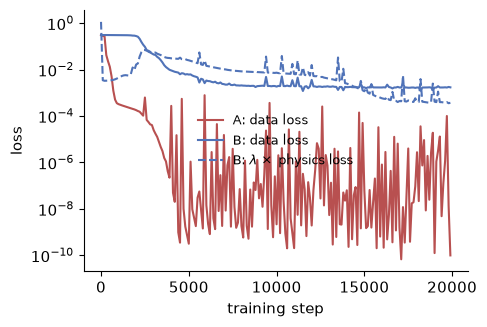

total runtime: 59 s


In [6]:
fig, ax = plt.subplots(figsize=(5, 3.4))
ax.semilogy(hist_A[:, 0], hist_A[:, 1], color=RED, label="A: data loss")
ax.semilogy(hist_B[:, 0], hist_B[:, 1], color=BLUE, label="B: data loss")
ax.semilogy(hist_B[:, 0], hist_B[:, 2], color=BLUE, ls="--", label=r"B: $\lambda\,\times$ physics loss")
ax.set_xlabel("training step")
ax.set_ylabel("loss")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("figures/fig_I_loss.pdf")
plt.show()

print(f"total runtime: {time.time() - t_start:.0f} s")